In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载 Day 15 的基准模型（用于对比）
try:
    baseline_xgb = joblib.load('../models/day15_xgboost_default.pkl')
    baseline_test_r2 = baseline_xgb.score(X_test, y_test)
    print(f"\n基准模型（Day 15 默认参数）测试集 R²: {baseline_test_r2:.4f}")
except:
    print("\n未找到基准模型，将创建一个")
    baseline_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    baseline_xgb.fit(X_train, y_train)
    baseline_test_r2 = baseline_xgb.score(X_test, y_test)

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本

基准模型（Day 15 默认参数）测试集 R²: 0.6178



实验 1：max_depth 对性能的影响

training max_depth=3...
  Train R²: 0.8708
  Test R²: 0.6171
  Gap: 0.2537
  Time: 0.25s

training max_depth=4...
  Train R²: 0.9485
  Test R²: 0.6148
  Gap: 0.3337
  Time: 0.31s

training max_depth=5...
  Train R²: 0.9832
  Test R²: 0.5935
  Gap: 0.3898
  Time: 0.33s

training max_depth=6...
  Train R²: 0.9929
  Test R²: 0.6178
  Gap: 0.3751
  Time: 0.44s

training max_depth=7...
  Train R²: 0.9960
  Test R²: 0.5650
  Gap: 0.4310
  Time: 0.74s

training max_depth=8...
  Train R²: 0.9968
  Test R²: 0.6430
  Gap: 0.3537
  Time: 0.98s

training max_depth=9...
  Train R²: 0.9969
  Test R²: 0.5984
  Gap: 0.3985
  Time: 1.80s

training max_depth=10...
  Train R²: 0.9970
  Test R²: 0.6170
  Gap: 0.3799
  Time: 1.83s

Best max_depth: 8 (Test R²=0.6430)


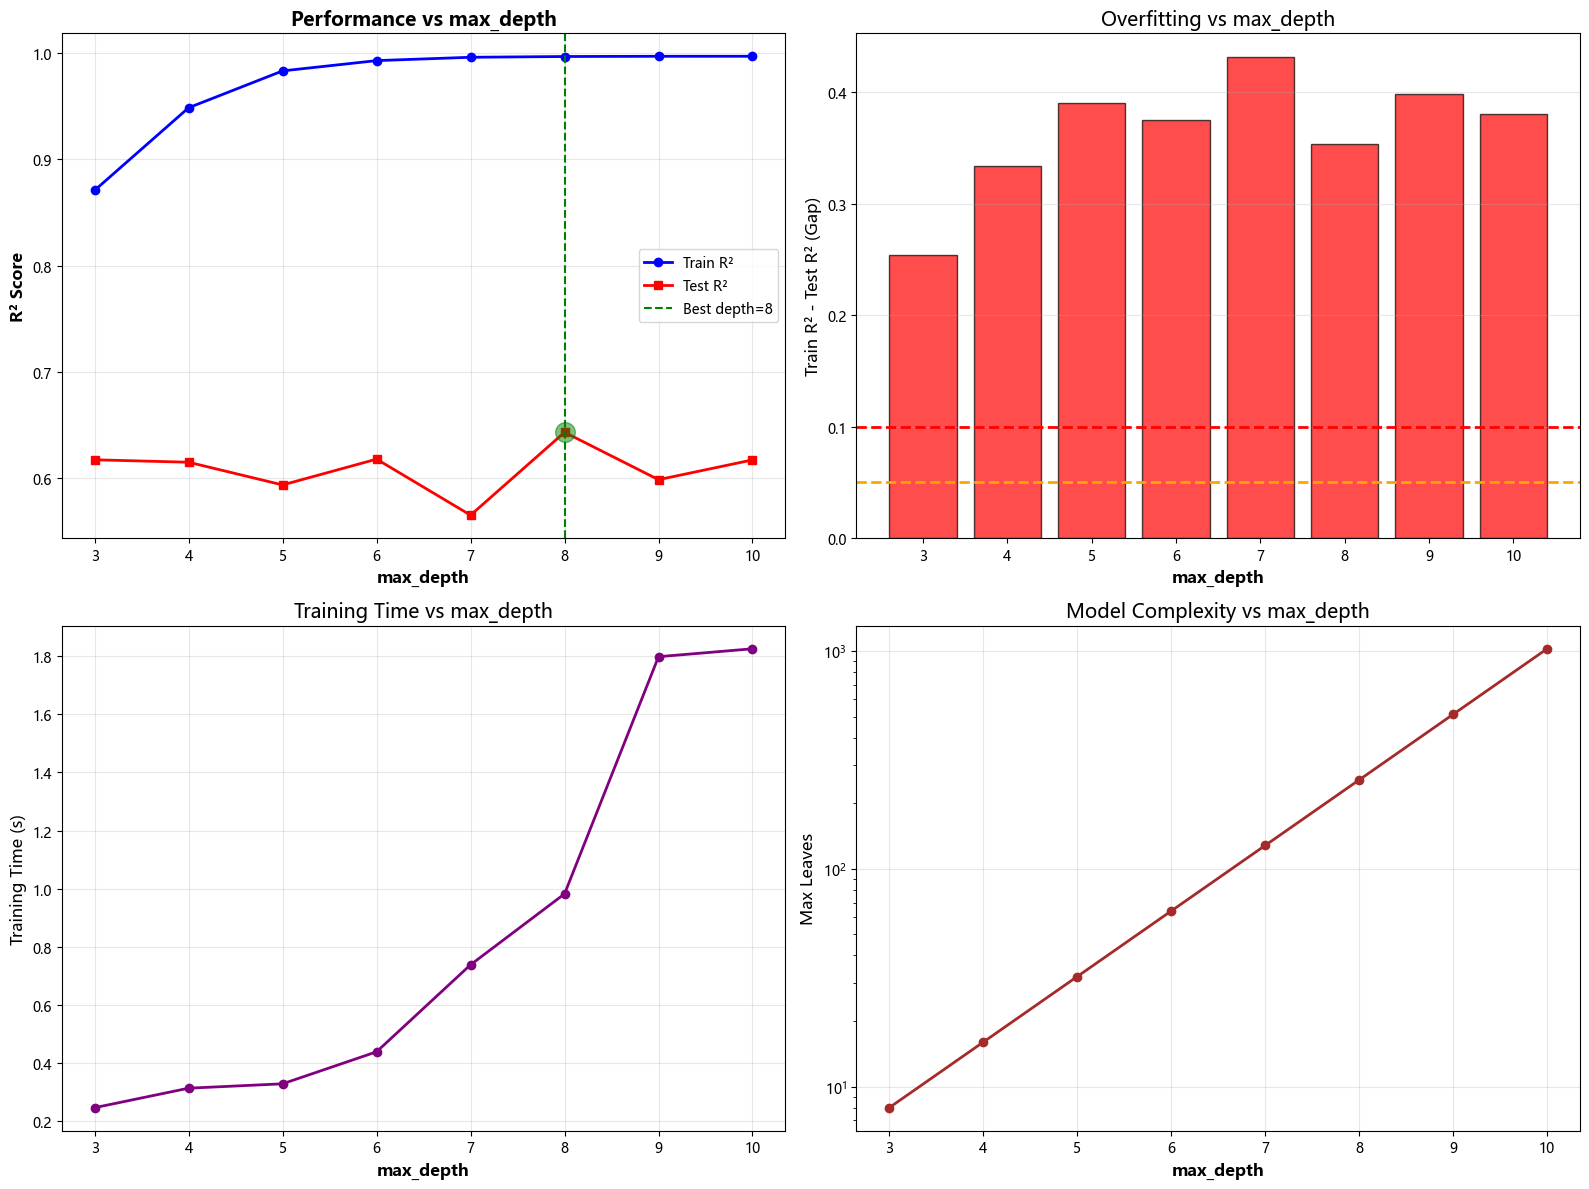


Image saved


In [8]:
# max_depth 的影响
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("\n" + "="*70)
print("实验 1：max_depth 对性能的影响")
print("="*70)

depths = [3, 4, 5, 6, 7, 8, 9, 10]
train_scores = []
test_scores = []
train_times = []

for depth in depths:
    print(f"\ntraining max_depth={depth}...")
    
    model = xgb.XGBRegressor(
        max_depth=depth,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(X_train, y_train, verbose=False)
    elapsed = time.time() - start
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    train_times.append(elapsed)
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Gap: {train_r2 - test_r2:.4f}")
    print(f"  Time: {elapsed:.2f}s")

best_depth_idx = np.argmax(test_scores)
best_depth = depths[best_depth_idx]
best_test_r2 = test_scores[best_depth_idx]

print(f"\nBest max_depth: {best_depth} (Test R²={best_test_r2:.4f})")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ax1.plot(depths, train_scores, marker='o', linewidth=2, label='Train R²', color='blue')
ax1.plot(depths, test_scores, marker='s', linewidth=2, label='Test R²', color='red')
ax1.axvline(best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
ax1.scatter(best_depth, best_test_r2, s=200, color='green', zorder=5, alpha=0.5)
ax1.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs max_depth', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
gaps = np.array(train_scores) - np.array(test_scores)
colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in gaps]
ax2.bar(depths, gaps, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2)
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12)
ax2.set_title('Overfitting vs max_depth', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1, 0]
ax3.plot(depths, train_times, marker='o', linewidth=2, color='purple')
ax3.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax3.set_ylabel('Training Time (s)', fontsize=12)
ax3.set_title('Training Time vs max_depth', fontsize=14)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(depths, [2**d for d in depths], marker='o', linewidth=2, color='brown')
ax4.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax4.set_ylabel('Max Leaves', fontsize=12)
ax4.set_title('Model Complexity vs max_depth', fontsize=14)
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day16_xgb_max_depth_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nImage saved")


实验 2：subsample 对性能的影响

训练 subsample=0.5...
  训练集 R²: 0.9900
  测试集 R²: 0.5946
  差距: 0.3954

训练 subsample=0.6...
  训练集 R²: 0.9929
  测试集 R²: 0.5830
  差距: 0.4100

训练 subsample=0.7...
  训练集 R²: 0.9947
  测试集 R²: 0.5950
  差距: 0.3997

训练 subsample=0.8...
  训练集 R²: 0.9953
  测试集 R²: 0.6135
  差距: 0.3818

训练 subsample=0.9...
  训练集 R²: 0.9962
  测试集 R²: 0.6293
  差距: 0.3670

训练 subsample=1.0...
  训练集 R²: 0.9968
  测试集 R²: 0.6430
  差距: 0.3537

最佳 subsample: 1.0 (测试集 R²=0.6430)


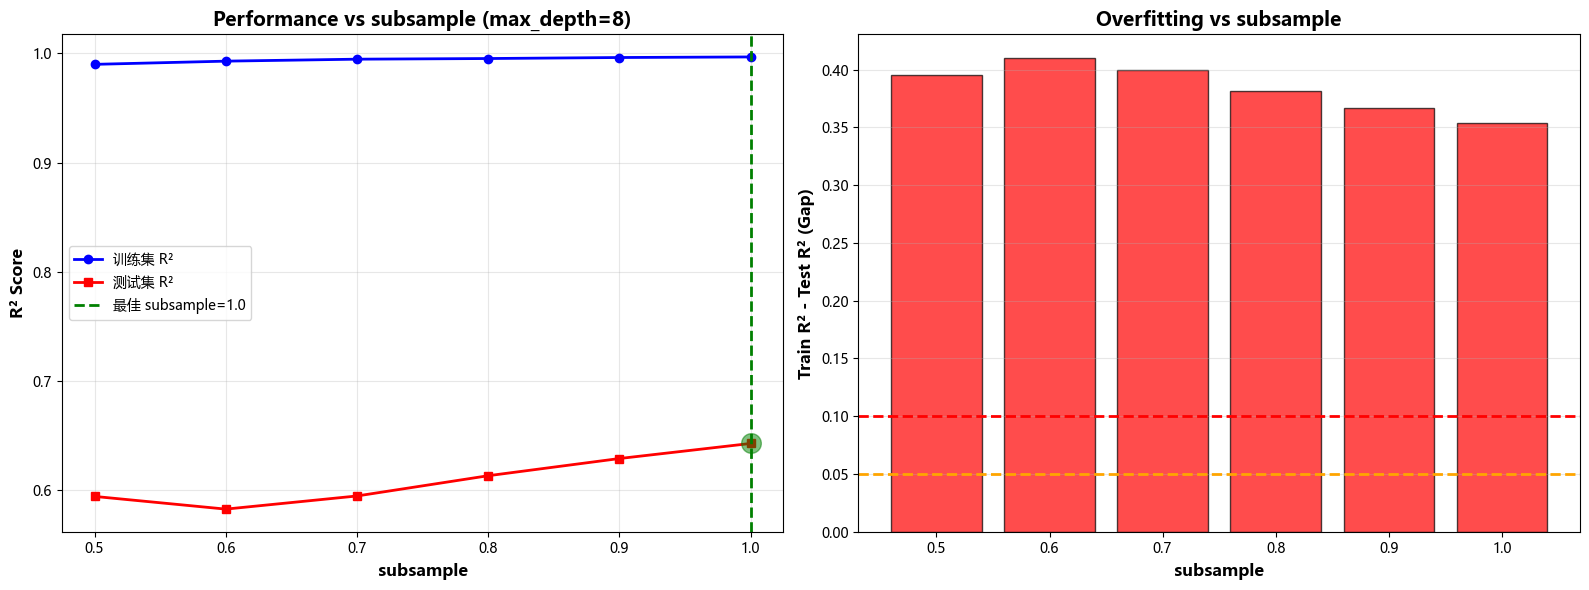


✓ subsample 分析图已保存


In [9]:
# sub sample的影响
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*70)
print("实验 2：subsample 对性能的影响")
print("="*70)

# 固定最佳 max_depth，测试不同的 subsample
subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
subsample_train_scores = []
subsample_test_scores = []

for sub in subsamples:
    print(f"\n训练 subsample={sub}...")
    
    model = xgb.XGBRegressor(
        max_depth=best_depth,
        subsample=sub,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train, verbose=False)
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    subsample_train_scores.append(train_r2)
    subsample_test_scores.append(test_r2)
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  差距: {train_r2 - test_r2:.4f}")

# 找到最佳 subsample
best_subsample_idx = np.argmax(subsample_test_scores)
best_subsample = subsamples[best_subsample_idx]
best_subsample_test_r2 = subsample_test_scores[best_subsample_idx]

print(f"\n最佳 subsample: {best_subsample} (测试集 R²={best_subsample_test_r2:.4f})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² vs subsample
ax1 = axes[0]
ax1.plot(subsamples, subsample_train_scores, marker='o', linewidth=2, 
         label='训练集 R²', color='blue')
ax1.plot(subsamples, subsample_test_scores, marker='s', linewidth=2, 
         label='测试集 R²', color='red')
ax1.axvline(best_subsample, color='green', linestyle='--', linewidth=2,
            label=f'最佳 subsample={best_subsample}')
ax1.scatter(best_subsample, best_subsample_test_r2, s=200, color='green', zorder=5, alpha=0.5)
ax1.set_xlabel('subsample', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Performance vs subsample (max_depth={best_depth})', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：过拟合程度 vs subsample
ax2 = axes[1]
subsample_gaps = np.array(subsample_train_scores) - np.array(subsample_test_scores)
colors_sub = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in subsample_gaps]
bars_sub = ax2.bar(range(len(subsamples)), subsample_gaps, color=colors_sub, 
                   alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(subsamples)))
ax2.set_xticklabels(subsamples)
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2)
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('subsample', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting vs subsample', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/day16_xgb_subsample_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ subsample 分析图已保存")